👉 It takes a road traffic audio (.wav file) as input

👉 Converts the sound into a Log-Mel Spectrogram (visual representation of audio)

👉 Uses a CNN (deep learning model) to analyze patterns in the sound

👉 Outputs the traffic density level:
*   Low Traffic
*   Medium Traffic
*   High Traffic

dataset Link: https://www.kaggle.com/datasets/nilshmeier/road-traffic-audio/code

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username": "ayushsharma2006",\r\n  "key": "KGAT_846d70f297d360823fb4738677bdfbd1"\r\n}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d nilshmeier/road-traffic-audio
!unzip road-traffic-audio.zip

Dataset URL: https://www.kaggle.com/datasets/nilshmeier/road-traffic-audio
License(s): CC-BY-NC-SA-4.0
100% 309M/309M [00:02<00:00, 126MB/s]

Archive:  road-traffic-audio.zip
  inflating: Audio/High_01.wav       
  inflating: Audio/High_02.wav       
  inflating: Audio/High_03.wav       
  inflating: Audio/Low_01.wav        
  inflating: Audio/Low_02.wav        
  inflating: Audio/Low_03.wav        
  inflating: Audio/Moderate_01.wav   
  inflating: Audio/Moderate_02.wav   
  inflating: Audio/Moderate_03.wav   
  inflating: Audio/Sample_01.wav     
  inflating: Audio/Sample_02.wav     
  inflating: Audio/Sample_03.wav     
  inflating: Audio/Sample_04.wav     
  inflating: Audio/Sample_05.wav     
  inflating: Audio/Sample_06.wav     
  inflating: Audio/Sample_07.wav     
  inflating: Audio/Sample_08.wav     
  inflating: Audio/Sample_09.wav     
  inflating: Audio/Sample_10.wav     
  inflating: Audio/Sample_11.wav     
  inflating: Audio/Sample_12.wav     
  inflating: Audio/Sample_1

In [55]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score

In [56]:
BASE_PATH = "/content"
AUDIO_PATH = os.path.join(BASE_PATH, "Audio")

In [57]:
def extract_features_from_signal(y, sr):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    spec = librosa.feature.spectral_centroid(y=y, sr=sr)

    return np.hstack([
        np.mean(mfcc, axis=1),
        np.mean(chroma, axis=1),
        np.mean(spec)
    ])

In [58]:
def augment_audio(y, sr):
    noise = np.random.randn(len(y))
    y_noise = y + 0.005 * noise

    y_shift = np.roll(y, int(sr * 0.2))

    return [y, y_noise, y_shift]

In [59]:
X = []
y = []

for file in os.listdir(AUDIO_PATH):

    path = os.path.join(AUDIO_PATH, file)

    if "Low" in file:
        label = 0
    elif "Moderate" in file:
        label = 1
    elif "High" in file:
        label = 2
    else:
        continue  # skip Sample files

    y_audio, sr = librosa.load(path, sr=22050)

    augmented_versions = augment_audio(y_audio, sr)

    for aug in augmented_versions:
        features = extract_features_from_signal(aug, sr)

        X.append(features)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("Total samples after augmentation:", len(X))

Total samples after augmentation: 27


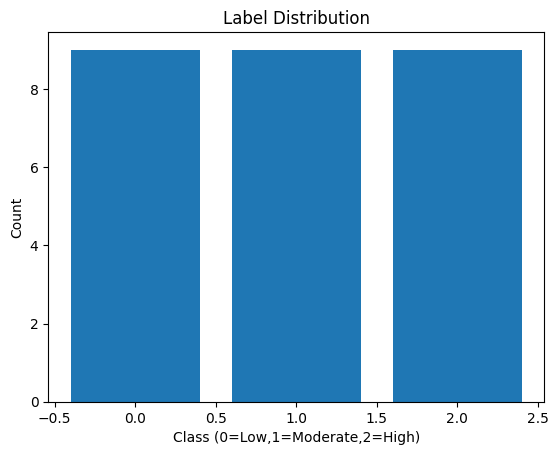

In [60]:
unique, counts = np.unique(y, return_counts=True)

plt.figure()
plt.bar(unique, counts)
plt.title("Label Distribution")
plt.xlabel("Class (0=Low,1=Moderate,2=High)")
plt.ylabel("Count")
plt.show()

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [62]:
model = RandomForestClassifier(n_estimators=200)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200)

In [63]:
scores = cross_val_score(model, X, y, cv=3)

print("Cross-validation scores:", scores)
print("Average accuracy:", scores.mean())

Cross-validation scores: [0.88888889 0.88888889 0.44444444]
Average accuracy: 0.7407407407407408


In [64]:
y_pred = model.predict(X_test)

In [65]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.67      0.57         3
           1       0.50      0.33      0.40         3
           2       1.00      1.00      1.00         3

    accuracy                           0.67         9
   macro avg       0.67      0.67      0.66         9
weighted avg       0.67      0.67      0.66         9

